#  Exploratory Data Analysis — Retail Store Sales

## Step 1Project Overview

This project performs Exploratory Data Analysis (EDA) on a cleaned retail store sales dataset. The analysis focuses on understanding the structure and characteristics of the data, identifying patterns and relationships, detecting potential outliers, and discovering useful trends through statistical analysis and visualization.

The cleaned dataset used in this project was prepared during **Task 1: Data Cleaning and Preprocessing**.

## Objectives

- Understand the distribution of numerical variables.
- Analyze relationships between important variables.
- Identify potential outliers and unusual observations.
- Explore patterns and trends within the dataset.
- Generate meaningful insights using statistical summaries and visualizations.

## Tools & Libraries

- Python
- Pandas
- Matplotlib
- Seaborn

## Expected Outcome

The analysis will provide a clearer understanding of the dataset and highlight the most important findings through statistical analysis, visualizations, and a **Top 3 Insights** section.

# Step 2 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 3 Load Dataset

In [2]:
df = pd.read_csv("retail_store_sales_cleaned.csv")

## Step 4 Initial Data Inspection

In [3]:
print("\nDataset Shape")
print(df.shape)
print("\nFirst Five Rows")
print(df.head())
print("\nDataset Information")
df.info()



Dataset Shape
(12575, 11)

First Five Rows
  Transaction ID Customer ID       Category          Item  Price Per Unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   

   Quantity  Total Spent  Payment Method Location Transaction Date  \
0      10.0        185.0  Digital Wallet   Online       2024-04-08   
1       9.0        261.0  Digital Wallet   Online       2023-07-23   
2       2.0         43.0     Credit Card   Online       2022-10-05   
3       9.0        247.5     Credit Card   Online       2022-05-07   
4       7.0         87.5  Digital Wallet   Online       2022-10-02   

  Discount Applied  
0             True  
1             True  
2        

In [5]:
print("Checking for Duplicates")
print(df.duplicated().sum())

Checking for Duplicates
0


#### Key Observation
The dataset is fully cleaned, None of the missing values and duplicates found

###  Step 5 Summary Statistics

In [6]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,12575.000000,12575.000000,12575.000000
mean,23.348191,5.558648,128.636581
std,10.480413,2.790160,92.557580
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,55.000000
50%,23.000000,6.000000,108.500000
75%,32.000000,8.000000,184.000000
max,41.000000,10.000000,410.000000


### Step 6 Univariate Analysis
The Term Univariate means ,it includes one variable/column at a time foe analysis

In [7]:
print("Identifying Numerical Columns")
numeric_columns = df.select_dtypes(include='number').columns
numeric_columns

Identifying Numerical Columns


Index(['Price Per Unit', 'Quantity', 'Total Spent'], dtype='object')

### Visualization

#### Histogram

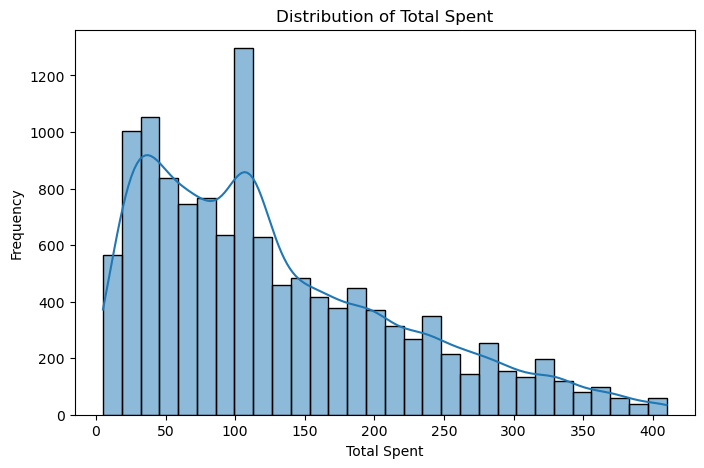

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='Total Spent', bins=30, kde=True)

plt.title('Distribution of Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')

plt.show()

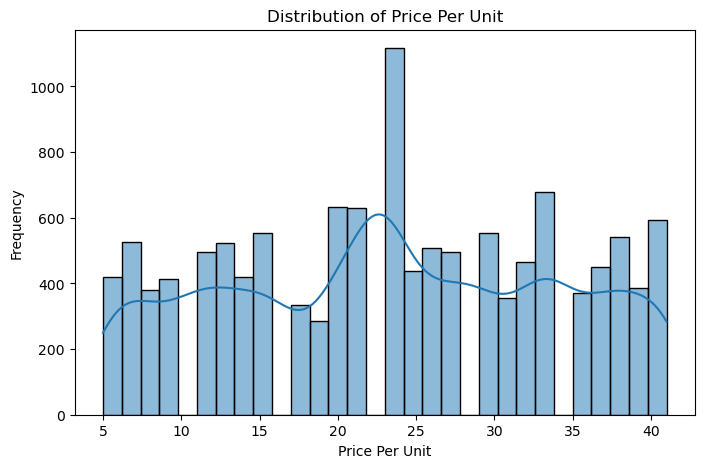

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='Price Per Unit', bins=30, kde=True)

plt.title('Distribution of Price Per Unit')
plt.xlabel('Price Per Unit')
plt.ylabel('Frequency')

plt.show()

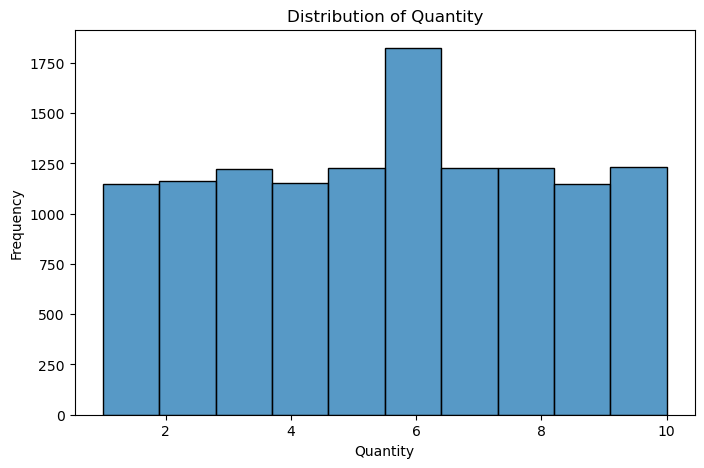

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='Quantity', bins=10, kde=False)

plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.show()

### Step 7 Categorical Analysis

#### Identifying Categorical Variables

In [10]:
categorical_columns = df.select_dtypes(include='object').columns

categorical_columns

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Payment Method',
       'Location', 'Transaction Date', 'Discount Applied'],
      dtype='object')

In [11]:
df['Category'].value_counts()

Category
Furniture                             1591
Electric household essentials         1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64

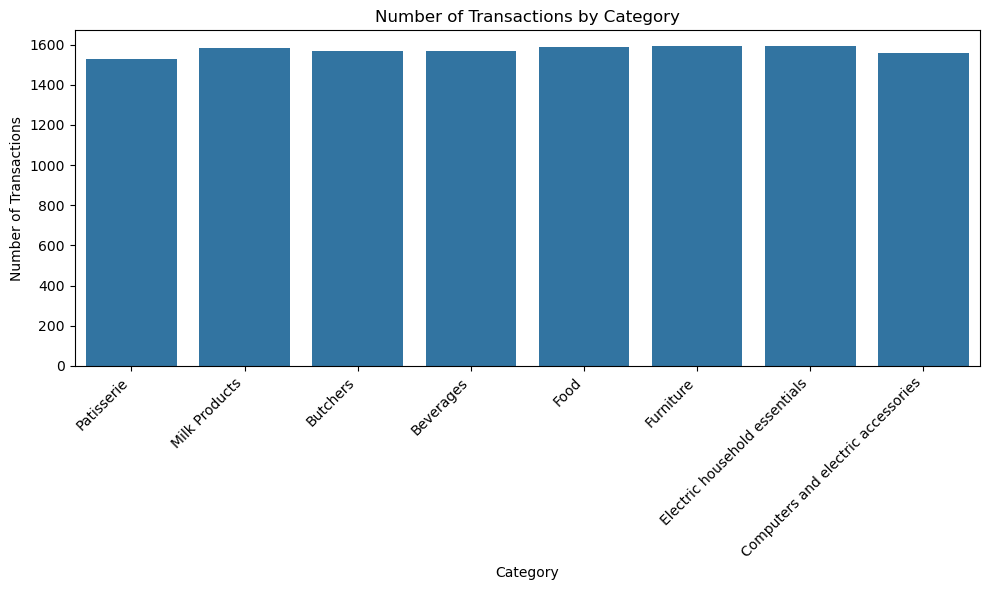

In [13]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='Category')

plt.title('Number of Transactions by Category')
plt.xlabel('Category')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Step 8 Outlier Detetion

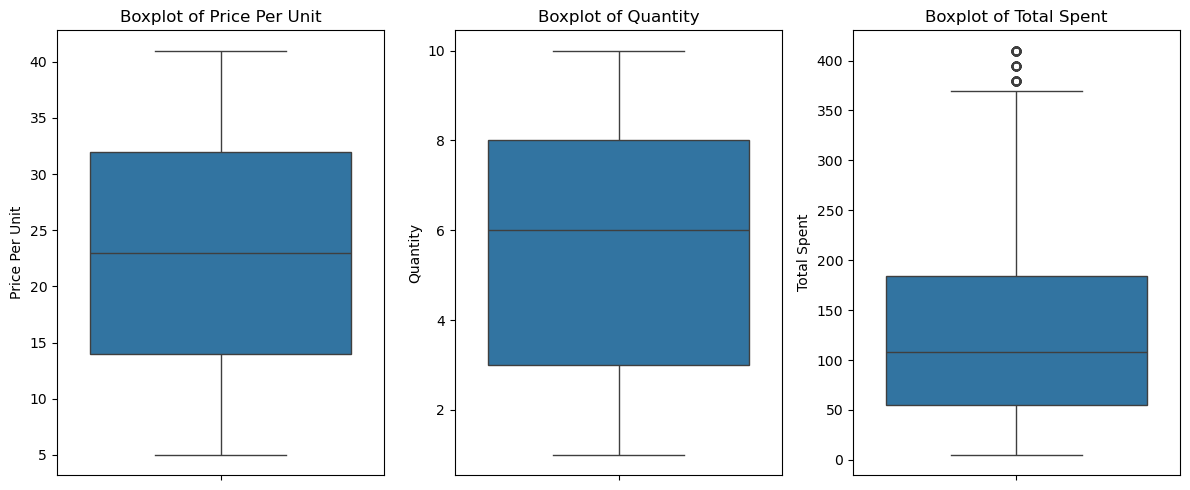

In [14]:
numerical_cols = ['Price Per Unit', 'Quantity', 'Total Spent']

plt.figure(figsize=(12, 5))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [15]:
corr = df[['Price Per Unit', 'Quantity', 'Total Spent']].corr()
corr

,Price Per Unit,Quantity,Total Spent
Price Per Unit,1.000000,0.011306,0.597021
Quantity,0.011306,1.000000,0.709033
Total Spent,0.597021,0.709033,1.000000


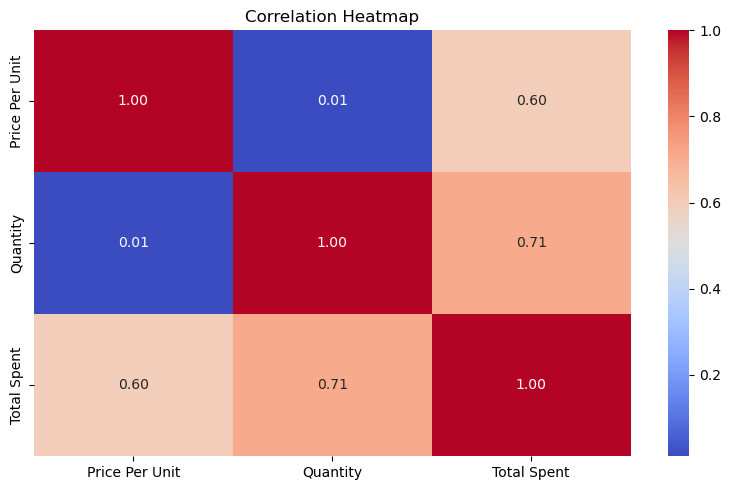

In [16]:
plt.figure(figsize=(8, 5))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Step 9 Written Obseration for every Chart

## Overall EDA Observations

The analysis shows that `Total Spent` is right-skewed, while `Quantity` has a noticeable concentration around 6 and transaction volumes are relatively balanced across categories.  
Outlier analysis found no statistical outliers in `Price Per Unit` or `Quantity`, while `Total Spent` contains several high-value observations.  
Correlation analysis shows positive relationships of `Total Spent` with both `Quantity` (r = 0.71) and `Price Per Unit` (r = 0.60), while `Price Per Unit` and `Quantity` have almost no linear relationship (r = 0.01).v

## Top 3 Insights

1. **Quantity and Total Spent:** Quantity has the strongest positive correlation with Total Spent (**r = 0.71**), indicating that higher quantities tend to be associated with higher transaction spending.

2. **Spending Distribution & Outliers:** Total Spent is right-skewed and contains several high-value statistical outliers, while Price Per Unit and Quantity show no statistical outliers.

3. **Category & Purchase Patterns:** Transaction volumes are relatively balanced across categories, while Quantity shows a noticeable concentration around **6 units**.